In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [2]:
mcmc_4 = np.load("mcmc_results_4/avg_wd_mcmc.npy")
mcmc_0 = np.load("mcmc_results_0/avg_wd_mcmc.npy")
mcmc_1 = np.load("mcmc_results/avg_wd_mcmc.npy")
sample_no_list = np.load("sample_no_list.npy").tolist()

In [3]:
no_trials = 10

df_sde = pd.read_csv("sde_4.csv")
sde_mean_4 = df_sde.iloc[:, 1].to_numpy()

df_sde = pd.read_csv("sde_0.csv")
sde_mean_0 = df_sde.iloc[:, 1].to_numpy()

df_sde = pd.read_csv("sde_1.csv")
sde_mean_1 = df_sde.iloc[:, 1].to_numpy()

In [4]:
ode_array_4 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_4[i, :] = np.load(f"converge_results_4/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_4 = np.mean(ode_array_4, axis=0)

ode_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_0[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_0 = np.mean(ode_array_0, axis=0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_banana/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_1 = np.mean(ode_array_1, axis=0)

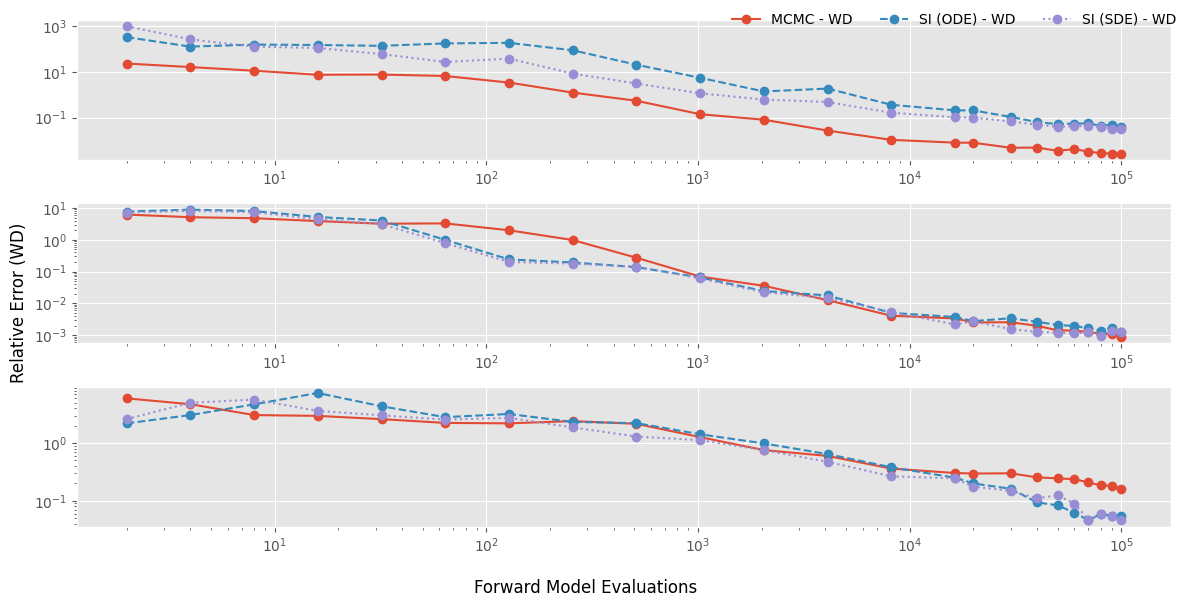

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,6))

ax[0].plot(sample_no_list, mcmc_0, marker="o", label="MCMC - WD")
ax[0].plot(sample_no_list, ode_mean_0, marker="o", linestyle="dashed", label="SI (ODE) - WD")
ax[0].plot(sample_no_list, sde_mean_0, marker="o", linestyle="dotted", label="SI (SDE) - WD")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[1].plot(sample_no_list, mcmc_1, marker="o")
ax[1].plot(sample_no_list, ode_mean_1, marker="o", linestyle="dashed")
ax[1].plot(sample_no_list, sde_mean_1, marker="o", linestyle="dotted")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[2].plot(sample_no_list, mcmc_4, marker="o")
ax[2].plot(sample_no_list, ode_mean_4, marker="o", linestyle="dashed")
ax[2].plot(sample_no_list, sde_mean_4, marker="o", linestyle="dotted")
ax[2].set_xscale("log")
ax[2].set_yscale("log")

fig.supylabel("Relative Error (W2)")
fig.supxlabel("Forward Model Evaluations")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False
)

plt.tight_layout()

In [54]:
mcmc_samps = np.load("mcmc_results_4/mcmc_samps.npy")
mcmc_samps_flat = np.empty((10, 100000, 1))
for i in range(10):
    mcmc_samps_flat[i, :, :] = np.vstack(mcmc_samps[i, :, :, :])

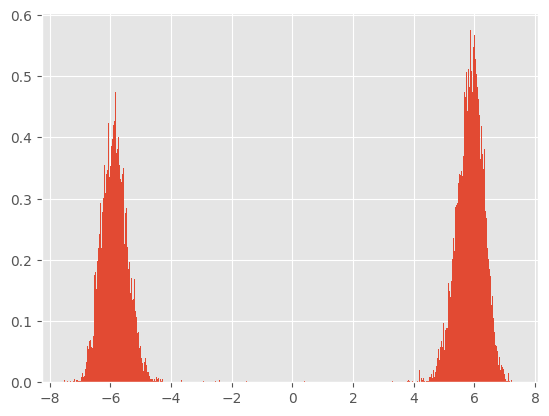

In [61]:
plt.hist(mcmc_samps_flat[0, :, :], bins = 1000, density=True);

<Axes: ylabel='Density'>

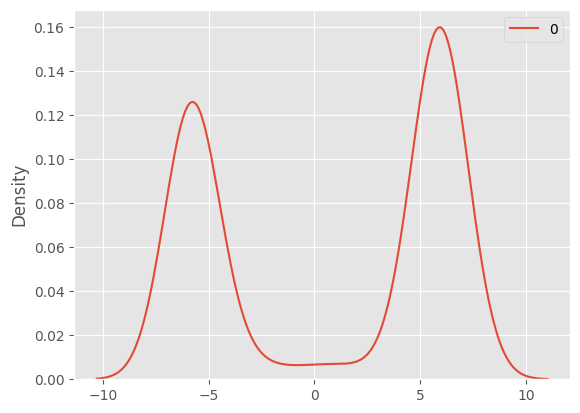

In [80]:
samp = mcmc_samps[0]
sample_no = 512 * 4
kdeplot(samp[:, : sample_no // 16, :].reshape(sample_no, 1))

In [83]:
rng = np.random.RandomState(1)
rej_samps = np.load("rej_samples_4.npy")[
    rng.choice(100000, size=(20000,)), :
]

In [95]:
samp = mcmc_samps[0]
sample_no = 512 * 128
wd(
    samp[:, : sample_no // 16, :].reshape(sample_no, ),
    rej_samps.reshape(-1),
    p=2
)

np.float64(6.964410224492431)

This shows that earlier on, the chain is actually closer to the target. The tailing off is actually a feature of the MCMC, not a bug

In [94]:
512 * 128

65536